In [1]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt

file_path = "data/eda/diamonds.csv"
df = pd.read_csv(file_path, dtype=str)

In [3]:
num_cols = ["carat", "depth", "table", "x", "y", "z", "price"]
cat_cols = ["cut", "color", "clarity"]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# One column - same as case 1 of the logistic regression

In [4]:
df['is_ideal'] = (df['cut'] == 'Ideal').astype(int)

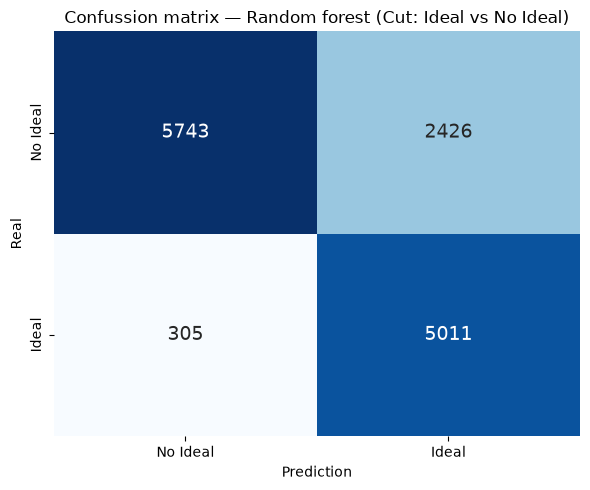

Accuracy:  0.7975
Precision: 0.6738
Recall:    0.9426
F1-score:  0.7859


In [5]:
X_simple = df[["table"]]
y_simple = df["is_ideal"]

model_simple = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("random_forest", RandomForestClassifier()),
])

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.25, random_state=777)

model_simple.fit(X_train_simple, y_train_simple) # Here we fit and transform the information
y_pred_simple = model_simple.predict(X_test_simple) # Here we only trasnform and predict

# Metrics
cm = confusion_matrix(y_test_simple, y_pred_simple)
acc = accuracy_score(y_test_simple, y_pred_simple)
prec = precision_score(y_test_simple, y_pred_simple)
rec = recall_score(y_test_simple, y_pred_simple)
f1 = f1_score(y_test_simple, y_pred_simple)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Ideal', 'Ideal'],
            yticklabels=['No Ideal', 'Ideal'],
            cbar=False, annot_kws={'size': 14})
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confussion matrix — Random forest (Cut: Ideal vs No Ideal)')
plt.tight_layout()
plt.show()

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Two columns - same as case 2 of the logistic regression

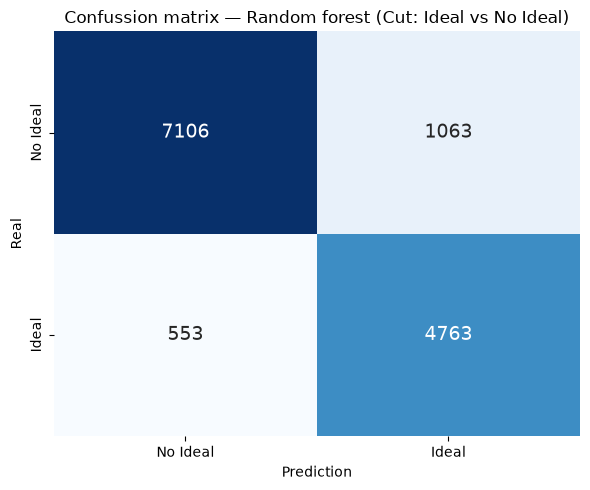

Accuracy:  0.8802
Precision: 0.8175
Recall:    0.8960
F1-score:  0.8550


In [6]:
X_two = df[["table" , "depth"]]
y_two = df["is_ideal"]

model_two = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("regression", RandomForestClassifier()),
])

X_train_two, X_test_two, y_train_two, y_test_two = train_test_split(X_two, y_two, test_size=0.25, random_state=777)

model_two.fit(X_train_two, y_train_two) # Here we fit and transform the information
y_pred_two = model_two.predict(X_test_two) # Here we only trasnform and predict

# Metrics
cm = confusion_matrix(y_test_two, y_pred_two)
acc = accuracy_score(y_test_two, y_pred_two)
prec = precision_score(y_test_two, y_pred_two)
rec = recall_score(y_test_two, y_pred_two)
f1 = f1_score(y_test_two, y_pred_two)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Ideal', 'Ideal'],
            yticklabels=['No Ideal', 'Ideal'],
            cbar=False, annot_kws={'size': 14})
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confussion matrix — Random forest (Cut: Ideal vs No Ideal)')
plt.tight_layout()
plt.show()
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# All columns and multiclass prediction

In [7]:
cut_order = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}

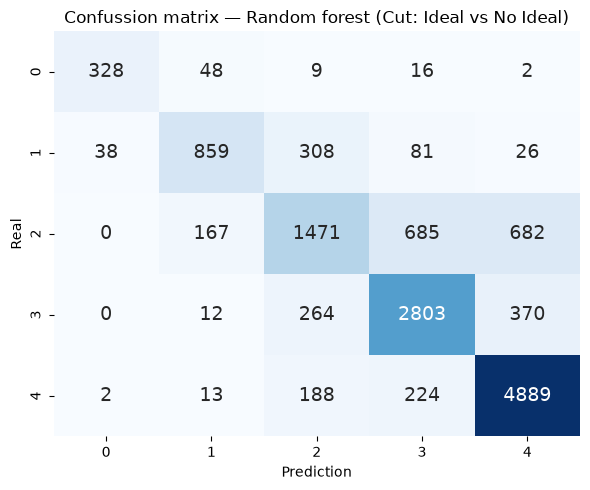

Accuracy:  0.7675
              precision    recall  f1-score   support

           0       0.89      0.81      0.85       403
           1       0.78      0.65      0.71      1312
           2       0.66      0.49      0.56      3005
           3       0.74      0.81      0.77      3449
           4       0.82      0.92      0.87      5316

    accuracy                           0.77     13485
   macro avg       0.78      0.74      0.75     13485
weighted avg       0.76      0.77      0.76     13485



In [8]:
num_cols = ["carat", "depth", "table", "x", "y", "z", "price"]
cat_cols = ["color", "clarity"]

X = df[num_cols + cat_cols]
y = df["cut"]
y = df['cut'].map(cut_order)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

catecorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder()),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", catecorical_pipeline, cat_cols),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("regression", RandomForestClassifier(
        criterion="gini",
        n_estimators=100
    )),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=777)

model.fit(X_train, y_train) # Here we fit and transform the information
y_pred = model.predict(X_test) # Here we only trasnform and predict

# Metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            cbar=False, annot_kws={'size': 14})
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confussion matrix — Random forest (Cut: Ideal vs No Ideal)')
plt.tight_layout()
plt.show()
print(f"Accuracy:  {acc:.4f}")
print(report)


Making better decitions on columns!

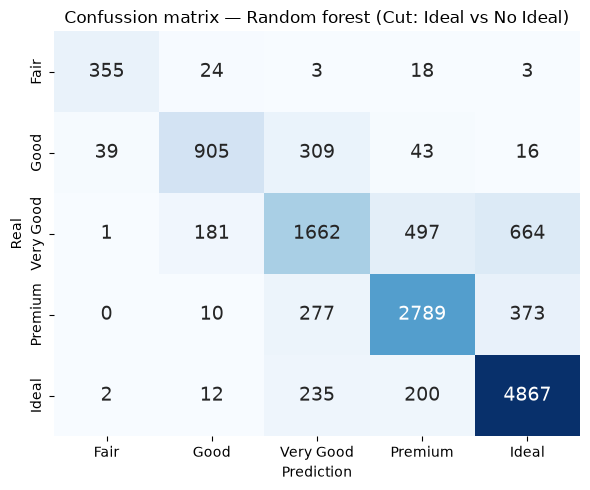

Accuracy:  0.7844
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       403
           1       0.80      0.69      0.74      1312
           2       0.67      0.55      0.61      3005
           3       0.79      0.81      0.80      3449
           4       0.82      0.92      0.87      5316

    accuracy                           0.78     13485
   macro avg       0.79      0.77      0.78     13485
weighted avg       0.78      0.78      0.78     13485



In [9]:
num_cols = ["carat", "depth", "table", "x", "y", "z", "price"]
cat_cols = []

X = df[num_cols + cat_cols]
y = df["cut"]
y = df['cut'].map(cut_order)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

catecorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder()),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", catecorical_pipeline, cat_cols),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("regression", RandomForestClassifier(
        criterion="gini",
        n_estimators=100
    )),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=777)

model.fit(X_train, y_train) # Here we fit and transform the information
y_pred = model.predict(X_test) # Here we only trasnform and predict

# Metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
            yticklabels=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
            cbar=False, annot_kws={'size': 14})
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confussion matrix — Random forest (Cut: Ideal vs No Ideal)')
plt.tight_layout()
plt.show()
print(f"Accuracy:  {acc:.4f}")
print(report)
